# Overview

This Jupyter Notebook provides a view of model results generated after executing `coco_eval.py` on the detection outputs of the YOLOv5 and YOLOv7 models. The main purpose is to evaluate how these models perform by analyzing the maximum attainable F1 scores obtained after running detection scripts with a very low Non-Maximum Suppression (NMS) confidence (NMS-conf = 0.001) and an array of NMS-IoU values (0.1 to 0.9 with a step of 0.1).

The primary metric for selecting the "best" model is the estimated maximum F1 score and its corresponding optimal NMS-conf and NMS-IoU values.

Once the best model is identified, detections are run in a next step with the optimal NMS-conf and NMS-IoU values for further evaluation.

This notebook requires the `general` environment (kernel). See ./envs/README.md for more information.

## A bit more about the metrics presented below

The key metrics presented in the table below are `maxF1` and also `AP_mean` ("mean average precision") & `AP_auc` (area under the precision-recall curve). All these 3 metrics were considered because they represent a balance between an optimal precision and recall trade-off. If we maximize recall, then precision will decrease, and vice versa.

`maxF1` was used in this study to pick the "best" insect detector, which represents the maximum achievable F1-score (which corresponds to a certain NMS confidence and NMS-IoU thresholds). The results stay the same if we pick the model with the highest AP_mean or AP_auc, as they are all correlated.

AP_mean & AP_auc, represent the same thing, but are calculated sightly differently with `pycocotools` library (see `coco_eval.py`). Both estimate the maximum attainable area under the precision-recall curve for a single class (class-agnostic) detector as evaluated in our study.

In the table below you can also find the TP, FP, FN, precision (P), recall (R), and F1 values calculated at an NMS confidence of 0.001 but are not that meaningful / informative by themselves at this low threshold. These metrics will be relevant when running the model at the corresponding maxF1conf and nms_iou (NMS confidence and IoU).

To add a bit more on that: at a NMS confidence threshold of 0.001, it's like allowing all the possible predictions (predicted boxes) to escape the NMS algorithm "barrier". It's like fishing with a fishnet - we tend to get most of TPs (our target insects), but also at the cost of lots of FPs (unwanted things - model "hallucinates"). So, TP & FP are maximized, and FNs are minimized. 

Since Precision (P) = TP / (TP + FP), and TP and TP + FP are both maximized then P is not informative since we would want to minimize FPs (not applicable with this evaluation). 

Recall (R) = TP / (TP + FN) is at its maximum possible value and it could be informative. It shows that if we run that model with the very low NMS-conf=0.001, then that is the maximum recall we can expect to achieve for that model. Anything higher than that it is improbable on the given dataset. So it is telling us the upper bound of the recall that can be achieved by the model. However, this comes at a huge cost of extra FPs, reducing the precision and F1 score drastically, something that is not desirable in practice for our study.

Since F1 is the harmonic mean of precision and recall, and precision is not informative at a very low NMS-conf of 0.001 due to the high number of false positives, F1 at this threshold is also not informative. 

However, the maxF1 value is highly informative. It represents the maximum F1 score (highest pick on the F1-Confidence curve) achievable by varying the confidence threshold from near 0 to near 1, as shown in the F1-confidence curves below. The peak of the F1-confidence curve (maxF1) indicates the confidence threshold that maximizes the F1 score. This confidence threshold is a good estimate for the NMS-confidence that can be used together with the optimal NMS-IoU to run the model in "production" on the given dataset.

Note that the evaluation was performed using an eval-IoU of 0.5 (this is different from NMS-IoU). It is the IoU threshold between a ground truth box and a predicted box to consider a detection as a true positive. This is usually a standard value used in object detection tasks. Lower values can of course be used and we explored also with 0.1. Such cases are practical for detecting frames with target objects regardless of the prediction overlap.

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import git

# Get the path to the project folder
prj_path = git.Repo('.', search_parent_directories=True).working_tree_dir
print(f"Root path of the project:\n'{prj_path}'")

Root path of the project:
'/scratch/vs66tavy/smartphone-insect-detect'


# "Best" model by maximizing F1 (`maxF1`)

In [2]:
df_eval_file_path = os.path.join(prj_path, 'data', 'processed', 'df_coco_eval_conf_0.001_ious_0.1_0.9.feather')
df_eval = pd.read_feather(df_eval_file_path)

# Convert nms_conf and nms_iou to numeric (float64)
df_eval['nms_conf'] = pd.to_numeric(df_eval['nms_conf'], errors='coerce')
df_eval['nms_iou'] = pd.to_numeric(df_eval['nms_iou'], errors='coerce')

df_eval.sort_values(by='maxF1', ascending=False, inplace=True)
cols = ['model', 'maxF1', 'AP_mean', 'AP_auc', 'maxF1conf', 'nms_iou']
df_eval[cols]

,model,maxF1,AP_mean,AP_auc,maxF1conf,nms_iou
0,yolov5s,0.701885,0.648232,0.649715,0.201918,0.3
17,yolov5s,0.701851,0.647788,0.649266,0.202188,0.4
1,yolov5s,0.701837,0.646993,0.648463,0.201686,0.2
15,yolov5s,0.701784,0.646849,0.648318,0.201151,0.1
8,yolov5s,0.701750,0.648188,0.649670,0.203343,0.5
10,yolov5s,0.701384,0.646878,0.648347,0.203757,0.6
14,yolov5s,0.700191,0.642076,0.643497,0.239306,0.7
21,yolov5s,0.693245,0.628728,0.630016,0.272606,0.8
4,yolov7-tiny,0.661738,0.628093,0.629374,0.223633,0.3
25,yolov7-tiny,0.661688,0.628537,0.629822,0.223755,0.4


<Figure size 1500x1000 with 0 Axes>

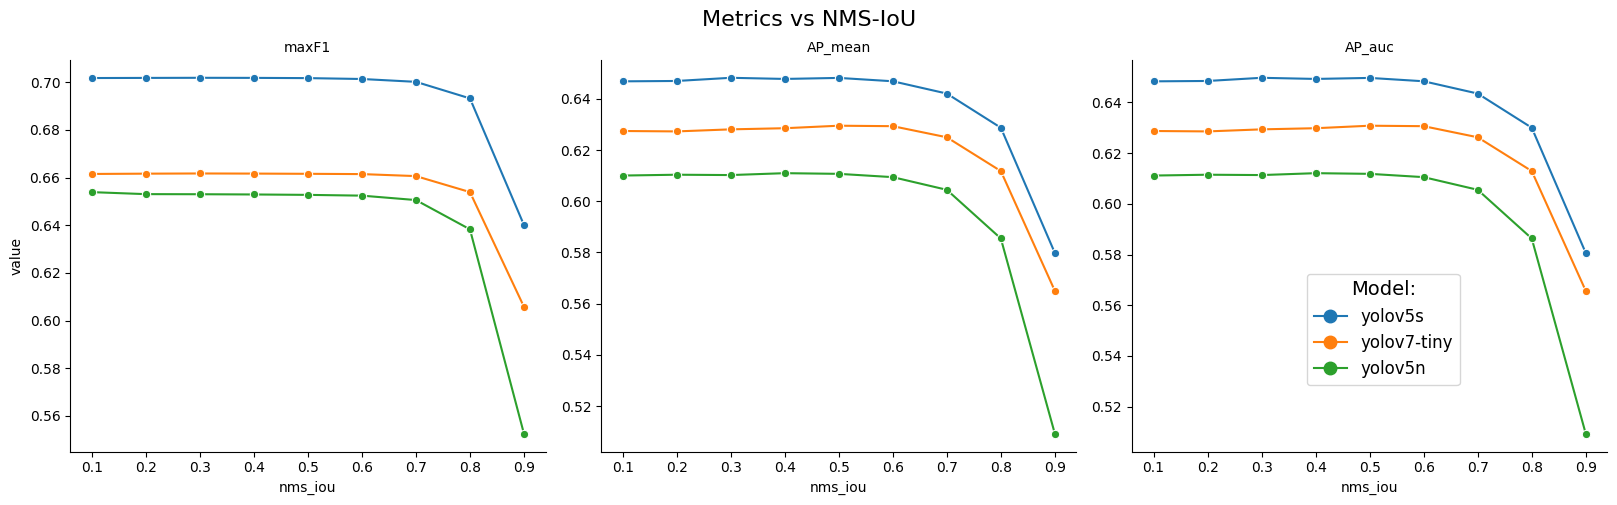

In [3]:
df = pd.melt(df_eval, id_vars=['model', 'nms_iou'], 
             value_vars=['maxF1', 'AP_mean', 'AP_auc'],
             var_name='variable', 
             value_name='value')

plt.figure(figsize=(15, 10))
g = sns.relplot(data=df, x='nms_iou', y='value', hue='model', 
                col='variable', col_wrap=3, kind='line', marker='o', 
                facet_kws={'sharey': False})
g.set_titles("{col_name}")
g.figure.suptitle('Metrics vs NMS-IoU', fontsize=16, y=1)
g.figure.tight_layout()
g.figure.subplots_adjust(top=0.9)
g._legend.remove()  # Remove the default legend
g.figure.legend(title='Model:', 
                bbox_to_anchor=(0.9, 0.25), 
                loc='lower right', 
                borderaxespad=0,
                fontsize=12, 
                title_fontsize=14, 
                markerscale=1.5)
plt.show()

Show the model with the highest maxF1.

Judging by maxF1 (and also AP_mean, AP_auc, that could be achieved if run at NMS-conf=maxF1conf=0.201918 and NMS-IoU=nms_iou=0.3), then yolov5s is the best model to investigate further.

Same "best" model is also confirmed by the AP_mean and AP_auc metrics.

In [4]:
df_eval[df_eval['maxF1'] == df_eval['maxF1'].max()][cols]

,model,maxF1,AP_mean,AP_auc,maxF1conf,nms_iou
0,yolov5s,0.701885,0.648232,0.649715,0.201918,0.3


In [5]:
# Show the model with the highest AP_auc - same as maxF1
df_eval[df_eval['AP_auc'] == df_eval['AP_auc'].max()][cols]

,model,maxF1,AP_mean,AP_auc,maxF1conf,nms_iou
0,yolov5s,0.701885,0.648232,0.649715,0.201918,0.3


In [6]:
# Show the model with the highest AP_mean - - same as maxF1
df_eval[df_eval['AP_mean'] == df_eval['AP_mean'].max()][cols]

,model,maxF1,AP_mean,AP_auc,maxF1conf,nms_iou
0,yolov5s,0.701885,0.648232,0.649715,0.201918,0.3


# F1-Confidence curves

In [7]:
df_f1s_file_path = os.path.join(prj_path, 'data', 'processed', 'df_coco_eval_conf_0.001_ious_0.1_0.9_arrays.feather')
df_f1s = pd.read_feather(df_f1s_file_path)

print(df_f1s.shape)
print(df_f1s.dtypes)
df_f1s.head()

(2727, 7)
P_array       float64
R_array       float64
conf_array    float64
F1_array      float64
model          object
nms_conf       object
nms_iou        object
dtype: object


,P_array,R_array,conf_array,F1_array,model,nms_conf,nms_iou
0,1.000000,0.00,0.939228,0.000000,yolov5s,0.001,0.3
1,1.000000,0.01,0.884570,0.019802,yolov5s,0.001,0.3
2,1.000000,0.02,0.875452,0.039216,yolov5s,0.001,0.3
3,1.000000,0.03,0.866645,0.058252,yolov5s,0.001,0.3
4,0.999241,0.04,0.858777,0.076921,yolov5s,0.001,0.3


In [8]:
# Convert nms_conf and nms_iou to numeric (float64)
df_f1s['nms_conf'] = pd.to_numeric(df_f1s['nms_conf'], errors='coerce')
df_f1s['nms_iou'] = pd.to_numeric(df_f1s['nms_iou'], errors='coerce')

df_f1s.describe(include='all')

,P_array,R_array,conf_array,F1_array,model,nms_conf,nms_iou
count,2727.000000,2727.000000,2727.000000,2727.000000,2727,2.727000e+03,2727.000000
unique,NaN,NaN,NaN,NaN,3,NaN,NaN
top,NaN,NaN,NaN,NaN,yolov5s,NaN,NaN
freq,NaN,NaN,NaN,NaN,909,NaN,NaN
mean,0.617351,0.500000,0.349327,0.311294,NaN,1.000000e-03,0.500000
std,0.425512,0.291601,0.316291,0.248521,NaN,2.168802e-19,0.258246
min,0.000000,0.000000,0.000000,0.000000,NaN,1.000000e-03,0.100000
25%,0.034924,0.250000,0.001370,0.000000,NaN,1.000000e-03,0.300000
50%,0.894314,0.500000,0.341064,0.318705,NaN,1.000000e-03,0.500000
75%,0.980881,0.750000,0.654297,0.551804,NaN,1.000000e-03,0.700000


<Figure size 1500x1000 with 0 Axes>

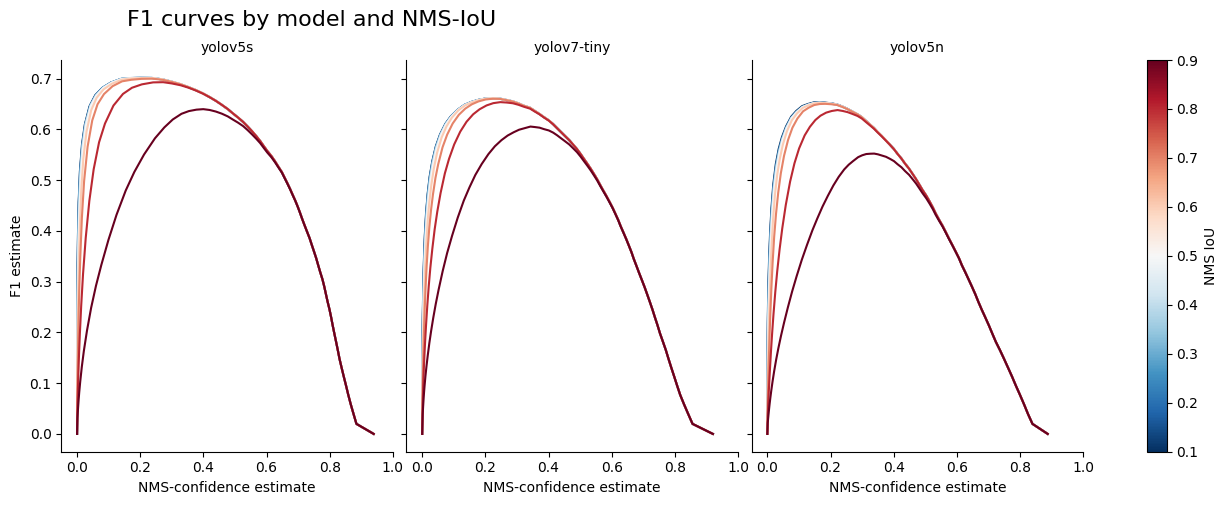

In [9]:
plt.figure(figsize=(15, 10))
g = sns.relplot(data=df_f1s, x='conf_array', y='F1_array', hue='nms_iou', 
                col='model', col_wrap=3, kind='line', 
                palette=sns.color_palette("RdBu_r", as_cmap=True),
                hue_norm=(0.1, 0.9),
                facet_kws={'sharey': True})
g.set_titles("{col_name}")
g.set_axis_labels('NMS-confidence estimate', 'F1 estimate')
g.figure.suptitle('F1 curves by model and NMS-IoU', fontsize=16, y=1, x=0.2)
g.figure.tight_layout()
g.figure.subplots_adjust(top=0.9, right=0.85)
g._legend.remove()
# Add a colorbar
norm = plt.Normalize(0.1, 0.9)
sm = plt.cm.ScalarMappable(cmap="RdBu_r", norm=norm)
sm.set_array([])
cbar = g.figure.colorbar(sm, ax=g.axes.ravel().tolist(), label='NMS IoU')
# Set x-axis limits for each subplot
for ax in g.axes.flat:
    ax.set_xlim(-0.05, 1)
plt.show()

# Precision-Recall curves

<Figure size 1500x1000 with 0 Axes>

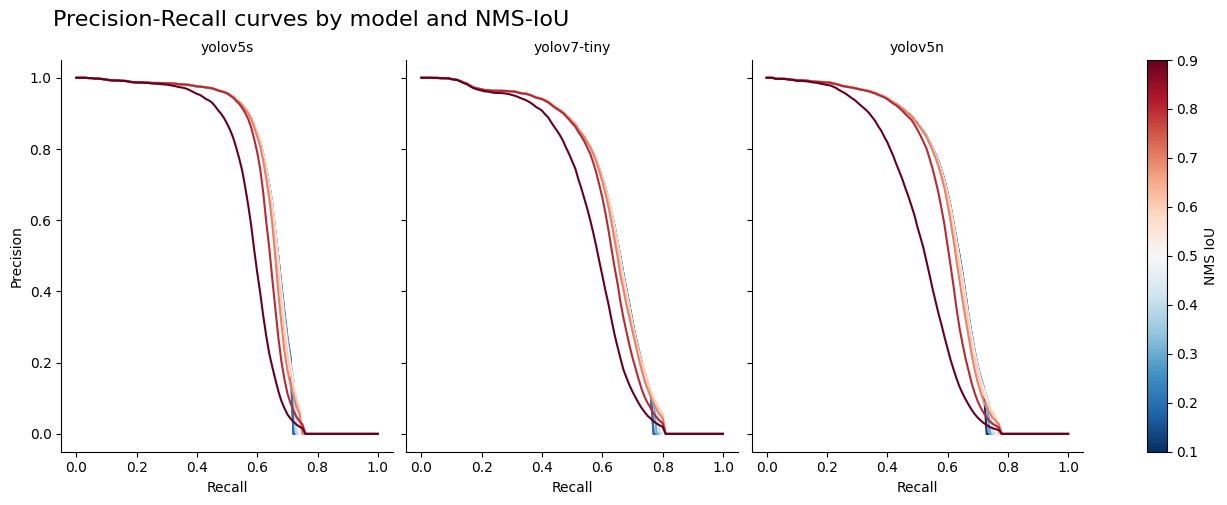

In [10]:
plt.figure(figsize=(15, 10))
g = sns.relplot(data=df_f1s, x='R_array', y='P_array', hue='nms_iou', 
                col='model', col_wrap=3, kind='line', 
                palette=sns.color_palette("RdBu_r", as_cmap=True),
                hue_norm=(0.1, 0.9),
                facet_kws={'sharey': True})
g.set_titles("{col_name}")
g.set_axis_labels('Recall', 'Precision')
g.figure.suptitle('Precision-Recall curves by model and NMS-IoU', fontsize=16, y=1, x=0.2)
g.figure.tight_layout()
g.figure.subplots_adjust(top=0.9, right=0.85)
g._legend.remove()
# Add a colorbar
norm = plt.Normalize(0.1, 0.9)
sm = plt.cm.ScalarMappable(cmap="RdBu_r", norm=norm)
sm.set_array([])
cbar = g.figure.colorbar(sm, ax=g.axes.ravel().tolist(), label='NMS IoU')
plt.show()